In [ ]:
# Import necessary libraries for data manipulation, visualization, text processing, and similarity calculation.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from wordcloud import WordCloud
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [ ]:
# Load the dataset from a CSV file into a pandas DataFrame.
# The 'engine' and 'on_bad_lines' parameters handle potential parsing issues in the CSV.
df = pd.read_csv('/content/spotify_millsongdata.csv', engine='python', on_bad_lines='warn')
# Display the first 5 rows of the DataFrame to get an overview of the data.
df.head()

,artist,song,link,text
0,ABBA,Ahe's My Kind Of Girl,/a/abba/ahes+my+kind+of+girl_20598417.html,"Look at her face, it's a wonderful face \r\nA..."
1,ABBA,"Andante, Andante",/a/abba/andante+andante_20002708.html,"Take it easy with me, please \r\nTouch me gen..."
2,ABBA,As Good As New,/a/abba/as+good+as+new_20003033.html,I'll never know why I had to go \r\nWhy I had...
3,ABBA,Bang,/a/abba/bang_20598415.html,Making somebody happy is a question of give an...
4,ABBA,Bang-A-Boomerang,/a/abba/bang+a+boomerang_20002668.html,Making somebody happy is a question of give an...


In [ ]:
# Display the number of rows and columns in the DataFrame.
df.shape

(57650, 4)

In [ ]:
# Get a concise summary of the DataFrame, including data types and non-null values for each column.
df.info

<bound method DataFrame.info of              artist                   song  \
0              ABBA  Ahe's My Kind Of Girl   
1              ABBA       Andante, Andante   
2              ABBA         As Good As New   
3              ABBA                   Bang   
4              ABBA       Bang-A-Boomerang   
...             ...                    ...   
57645  Ziggy Marley          Good Old Days   
57646  Ziggy Marley          Hand To Mouth   
57647          Zwan           Come With Me   
57648          Zwan                 Desire   
57649          Zwan              Heartsong   

                                              link  \
0       /a/abba/ahes+my+kind+of+girl_20598417.html   
1            /a/abba/andante+andante_20002708.html   
2             /a/abba/as+good+as+new_20003033.html   
3                       /a/abba/bang_20598415.html   
4           /a/abba/bang+a+boomerang_20002668.html   
...                                            ...   
57645  /z/ziggy+marley/good+old+days_10198588.html   
57646  /z/ziggy+marley/hand+to+mouth_20531167.html   
57647           /z/zwan/come+with+me_20148981.html   
57648                 /z/zwan/desire_20148986.html   
57649              /z/zwan/heartsong_20148991.html   

                                                    text  
0      Look at her face, it's a wonderful face  \r\nA...  
1      Take it easy with me, please  \r\nTouch me gen...  
2      I'll never know why I had to go  \r\nWhy I had...  
3      Making somebody happy is a question of give an...  
4      Making somebody happy is a question of give an...  
...                                                  ...  
57645  Irie days come on play  \r\nLet the angels fly...  
57646  Power to the workers  \r\nMore power  \r\nPowe...  
57647  all you need  \r\nis something i'll believe  \...  
57648  northern star  \r\nam i frightened  \r\nwhere ...  
57649  come in  \r\nmake yourself at home  \r\ni'm a ...  

[57650 rows x 4 columns]>

In [ ]:
# Generate descriptive statistics of the DataFrame's numerical columns.
# This provides insights into the central tendency, dispersion, and shape of the distribution.
df.describe()

,artist,song,link,text
count,57650,57650,57650,57650
unique,643,44824,57650,57494
top,Donna Summer,Have Yourself A Merry Little Christmas,/z/zwan/heartsong_20148991.html,I've got sunshine on a cloudy day \r\nWhen it...
freq,191,35,1,6


In [ ]:
# Check for missing values in each column of the DataFrame.
# '.sum()' aggregates the count of missing values per column.
df.isnull().sum()

,0
artist,0
song,0
link,0
text,0


In [ ]:
# Calculate the frequency of each artist and display the top 10 artists.
top_artist = df['artist'].value_counts().head(10)
print("\n Top 10 Artists \n")
print(top_artist)


 Top 10 Artists 

artist
Donna Summer        191
Gordon Lightfoot    189
Bob Dylan           188
George Strait       188
Loretta Lynn        187
Alabama             187
Cher                187
Reba Mcentire       187
Chaka Khan          186
Dean Martin         186
Name: count, dtype: int64


In [ ]:
# Sample 10,000 random rows from the DataFrame for faster processing.
df = df.sample(10000)
# Drop the 'link' column as it is not needed for song recommendations.
# Reset the DataFrame index after dropping the column.
df = df.drop('link', axis=1).reset_index(drop=True)

In [ ]:
# Concatenate all song lyrics into a single string, dropping any NaN values.
all_lyrics = " ".join(df['text'].dropna())
# Generate a WordCloud image from the concatenated lyrics.
# The WordCloud visualizes the frequency of words, with larger words appearing more often.
wordcloud = WordCloud(width=800, height=500, background_color='white').generate(all_lyrics)

<function matplotlib.pyplot.show(close=None, block=None)>

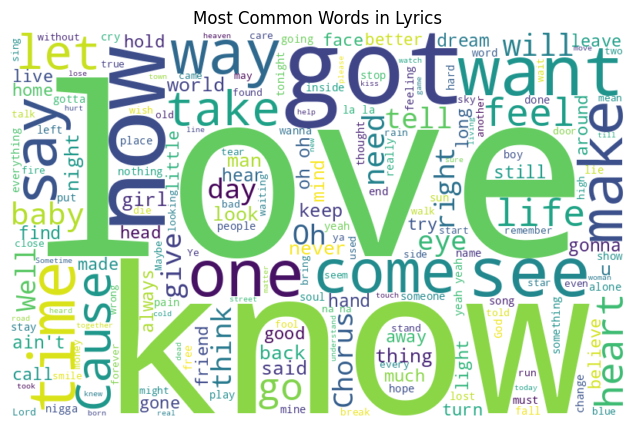

In [ ]:
# Create a new figure for plotting with a specified size.
plt.figure(figsize=(10, 5))
# Display the generated WordCloud image.
plt.imshow(wordcloud, interpolation='bilinear')
# Turn off the axis ticks and labels for a cleaner visualization.
plt.axis('off')
# Set the title of the plot.
plt.title('Most Common Words in Lyrics')
# Display the plot.
plt.show

In [ ]:
# Download necessary NLTK data: 'stopwords' for common words to be filtered out,
# and 'punkt' for sentence tokenization.
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
# Initialize a set of English stop words. These are common words like 'the', 'is', 'and' that are usually removed during text preprocessing.
stop_words = set(stopwords.words('english'))

In [ ]:
# Define a function to preprocess text for natural language processing tasks.
def preprocess_text(text):
    # Remove all characters that are not letters or spaces.
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    # Convert the text to lowercase to ensure consistency.
    text = text.lower()

    # Tokenize the text into individual words.
    tokens = word_tokenize(text)
    # Remove stop words from the tokens.
    tokens = [word for word in tokens if word not in stop_words]
    # Join the cleaned tokens back into a single string.
    return " ".join(tokens)

In [ ]:
# Apply the 'preprocess_text' function to the 'text' column of the DataFrame.
# This creates a new column 'cleaned_text' containing the preprocessed lyrics.
df['cleaned_text'] = df['text'].apply(preprocess_text)

In [ ]:
# Initialize a TF-IDF Vectorizer with a maximum of 5000 features (unique words).
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
# Transform the 'cleaned_text' column into a TF-IDF matrix.
# This converts text data into a numerical format, representing the importance of words.
tfidf_matrix = tfidf_vectorizer.fit_transform(df['cleaned_text'])

In [ ]:
# Calculate the cosine similarity between all pairs of song lyrics based on their TF-IDF representations.
# The result is a square matrix where each element (i, j) represents the similarity between song i and song j.
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [ ]:
# Define a function to recommend songs based on cosine similarity.
def recommend_songs (song_name, cosine_sim=cosine_sim, df=df, top_n=5):
  # Find the index of the given song in the DataFrame.
  idx = df[df['song'].str.lower() == song_name.lower()].index
  # If the song is not found, print a message and return.
  if len(idx) == 0:
    print("Song not found in the dataset.")
    return
  # Get the first index if multiple songs have the same name.
  idx = idx[0]

  # Get the similarity scores for the chosen song with all other songs.
  sim_scores = list(enumerate(cosine_sim[idx]))
  # Sort the songs by similarity score in descending order.
  sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
  # Get the top N most similar songs (excluding the song itself).
  sim_scores = sim_scores[1:top_n+1]

  # Get the indices of the recommended songs.
  song_indices = [i[0] for i in sim_scores]

  # Return the artist and song names of the recommended songs.
  return df[['artist', 'song']].iloc[song_indices]

In [ ]:
# Access and display the song title at index 2 of the DataFrame.
df["song"][2]

'Sunny'

In [ ]:
# Print a header for the recommendations.
print("\nRecommendations for the song 'Dig Me':")
# Call the 'recommend_songs' function with 'Dig Me' as the input and store the results.
recommendations = recommend_songs('Dig Me')
# Print the DataFrame containing the recommended songs.
print(recommendations)


Recommendations for the song 'Dig Me':
Song not found in the dataset.
None


In [ ]:
# Print a message indicating that sample songs will be displayed.
print('Some available songs in the dataset:')
# Display 10 random song titles from the 'song' column of the DataFrame.
# This helps the user to pick an existing song for recommendations.
print(df['song'].sample(10).tolist())

Some available songs in the dataset:
['Show Me', "C'mon Everybody", 'Die Eier Von Satan', 'Needs His Woman', 'Black Cow', 'Heartbreak Hotel', 'Cool Cat', 'They Said You Needed Me', 'Altar Of Sacrifice', "I'd Have You Anytime"]
